In [1]:

import matplotlib.pyplot as plt
import torch
import torch.utils.data as data

from torch import Tensor
torch.set_default_dtype(torch.float64)


In [2]:
def two_moons(n: int, sigma: float = 1e-1) -> tuple[Tensor, Tensor]:
    theta = 2 * torch.pi * torch.rand(n)
    label = (theta > torch.pi).float()

    x = torch.stack(
        (
            torch.cos(theta) + label - 1 / 2,
            torch.sin(theta) + label / 2 - 1 / 4,
        ),
        axis=-1,
    )

    return torch.normal(x, sigma), label


X, Y = two_moons(200)

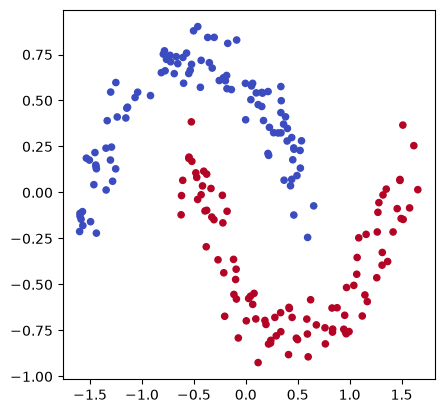

In [3]:
plt.figure(figsize=(4.8, 4.8))
plt.scatter(X[:, 0], X[:, 1], c=Y, cmap="coolwarm", s=20)

In [4]:
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np

from math import *


In [5]:
# torch.manual_seed(7777)

m, n = X.shape
h = 20  # num. hidden units per layer
k = 1  # num. of output unit


class Model(nn.Module):
    
    def __init__(self):
        super(Model, self).__init__()

        self.feature_map = nn.Sequential(
            nn.Linear(n, h),
            nn.BatchNorm1d(h),
            nn.ReLU(), 
            nn.Linear(h, h), 
            nn.BatchNorm1d(h),
            nn.ReLU()
        )

        self.clf = nn.Linear(h, 1, bias=False)
    
    def forward(self, x):
        x = self.feature_map(x)
        return self.clf(x)
    
    
X_train = X
y_train = Y
    
model = Model()
opt = optim.SGD(model.parameters(), lr=1e-3, momentum=0.9, weight_decay=5e-4)

for it in range(5000):
    y_pred = model(X_train).squeeze()
    l = F.binary_cross_entropy_with_logits(y_pred, y_train)
    l.backward()
    opt.step()
    opt.zero_grad()
        
print(f'Loss: {l.item():.3f}')

Loss: 0.006


In [6]:
x1 = torch.linspace(-5, 5, 100)
x2 = torch.linspace(-5, 5, 100)
X1, X2 = torch.meshgrid(x1, x2, indexing="ij")

X_test = torch.stack((X1.flatten(), X2.flatten()), dim=-1)

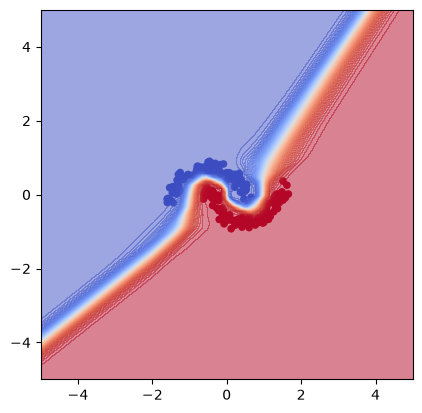

In [7]:
model.eval()

def sigmoid(x):
    return 1/(1+np.exp(-x))

with torch.no_grad():
    model.eval()
    py = sigmoid(model(X_test).squeeze().numpy())
    
conf = np.maximum(py, 1-py)

plt.figure(figsize=(4.8, 4.8))
plt.scatter(X[:, 0], X[:, 1], c=Y, cmap="coolwarm", s=20)
plt.contourf(X1, X2, py.reshape(X1.shape), levels=100, cmap="coolwarm", alpha=0.5)

C:\Users\stoennis\AppData\Local\Temp\ipykernel_24312\2433527366.py:56: UserWarning: linewidths is ignored by contourf
  plt.contourf(X1, X2, conf.reshape(X1.shape), levels=100, cmap='coolwarm', linewidths=2)


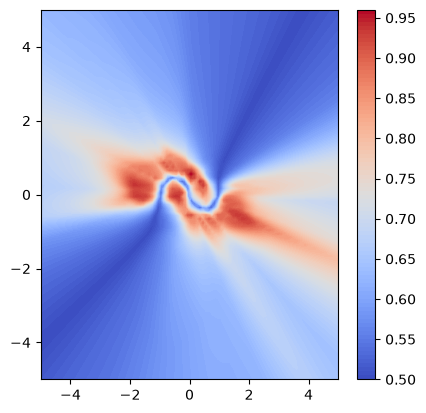

In [8]:
# Exact Hessian using PyTorch's autograd. Credits due to Felix Dangel.
from hessian import exact_hessian


W = list(model.parameters())[-1]
shape_W = W.shape

w_map = W.view(-1).data.numpy()


def neg_log_posterior(var0):
    # Negative-log-likelihood
    nll = F.binary_cross_entropy_with_logits(model(X_train).squeeze(), y_train, reduction='sum')
    # Negative-log-prior
    nlp = 1/2 * W.flatten() @ (1/var0 * torch.eye(W.numel())) @ W.flatten()
    
    return nll + nlp


def get_covariance(var0):
    # Outputs the inverse-Hessian of the negative-log-posterior at the MAP estimate
    # This is the posterior covariance
    loss = neg_log_posterior(var0)
    Lambda = exact_hessian(loss, [W])  # The Hessian of the negative log-posterior
    Sigma = torch.inverse(Lambda).detach().numpy()
    
    return Sigma


@torch.no_grad()
def predict(x, Sigma):    
    phi = model.feature_map(x).numpy()  # Feature vector of x
    m = phi @ w_map  # MAP prediction

    # "Moderate" the MAP prediction using the variance (see MacKay 1992 "Evidence Framework ...")
    # This is an approximation of the expected sigmoid (the so-called "probit approximation")
    v = np.diag(phi @ Sigma @ phi.T)
    py = sigmoid(m/np.sqrt(1 + pi/8 * v))
        
    return py


# The weight decay used for training is the Gaussian prior's precision
# Here we work in term of variance, which is just 1/precision.
var0 = 1/5e-4 

# Get the posterior covariance and make prediction
Sigma = get_covariance(var0)
py = predict(X_test, Sigma)

conf = np.maximum(py, 1-py)

plt.figure(figsize=(4.8, 4.8))
plt.scatter(X[:, 0], X[:, 1], c=Y, cmap="coolwarm", s=20)
# plt.contourf(X1, X2, py.reshape(X1.shape), levels=100, cmap="coolwarm", alpha=0.5)
plt.contourf(X1, X2, conf.reshape(X1.shape), levels=100, cmap='coolwarm', linewidths=2)
plt.colorbar()


In [11]:
def neg_log_prior(var0):
    nlp = 1 / 2 * W.flatten() @ (1 / var0 * torch.eye(W.numel())) @ W.flatten()
    return nlp

nlp = neg_log_prior(var0)
Lambda_nlp = exact_hessian(nlp, [W])
Sigma_nlp = torch.inverse(Lambda_nlp).detach().numpy()

def neg_log_likelihood():
    return F.binary_cross_entropy_with_logits(
        model(X_train).squeeze(),
        y_train,
        reduction="sum",
    )

nll = neg_log_likelihood()
Lambda_nll = exact_hessian(nll,[W])
Sigma_nll = torch.inverse(Lambda_nll).detach().numpy()

print(f"{Sigma_nlp=}")
print(f"{Sigma_nll=}")
print(f"{Sigma=}")

Sigma_nlp=array([[2000.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.],
       [   0., 2000.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.],
       [   0.,    0., 2000.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.],
       [   0.,    0.,    0., 2000.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.],
       [   0.,    0.,    0.,    0., 2000.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.],
       [   0.,    0.,    0.,    0.,    0., 2000.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.],


In [9]:
import math

import pyro

import pyro.distributions as dist
from pyro.infer import SVI, Predictive, Trace_ELBO
from pyro.infer.autoguide import AutoLaplaceApproximation, init_to_value, AutoNormal, AutoMultivariateNormal

from dataclasses import dataclass

c:\Users\stoennis\Desktop\UQHM\github\last_layer_laplace\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Four-way comparison: Laplace vs mean-field VI vs full-rank VI vs NUTS

All four posteriors are fitted over the **same frozen feature map**, so any
difference is attributable to the inference method alone.

The headline result is that Laplace and VI do *not* agree, and full-rank VI does
not close the gap - it lands on top of mean-field. See the discussion cell at
the bottom.

In [ ]:
import math
import numpy as np
import torch
import torch.nn as nn

import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Predictive, Trace_ELBO, MCMC, NUTS
from pyro.infer.autoguide import (
    AutoLaplaceApproximation,
    AutoNormal,
    AutoMultivariateNormal,
    init_to_value,
)
from pyro.optim import ClippedAdam

### The model

`init_to_value` is seeded with a **fan-in** draw, $\mathcal{U}(-1/\sqrt{h},
1/\sqrt{h})$. Note `h**-0.5`, not `h**-2` - the latter is ~90x too small and
starts every unit near zero.

In [ ]:
var0 = 1 / 5e-4                    # prior VARIANCE (== 1 / weight decay)
prior_scale = math.sqrt(var0)      # dist.Normal wants a STANDARD DEVIATION
print(f"prior_scale = {prior_scale:.3f}")


class BayesianMLP(pyro.nn.PyroModule):
    def __init__(self, n, h, prior_scale=1.0):
        super().__init__()
        self.h = h
        self.prior_scale = prior_scale
        self.feature_map = nn.Sequential(
            nn.Linear(n, h), nn.BatchNorm1d(h), nn.ReLU(),
            nn.Linear(h, h), nn.BatchNorm1d(h), nn.ReLU(),
        )
        self._guide = AutoLaplaceApproximation(
            self.model,
            init_loc_fn=init_to_value(values={"w": (torch.rand(h) * 2 - 1) * h**-0.5}),
        )

    def model(self, x, y=None):
        phi = self.feature_map(x)
        w = pyro.sample(
            "w", dist.Normal(torch.zeros(self.h), self.prior_scale).to_event(1)
        )
        logits = (phi @ w.unsqueeze(-1)).squeeze(-1)
        pyro.deterministic("logits", logits)
        with pyro.plate("data", x.shape[0]):
            pyro.sample("obs", dist.Bernoulli(logits=logits), obs=y)

    def guide(self, x, y=None):
        return self._guide(x, y)

### Stage 1 - fit the feature map (MLE) and the MAP of `w`

`AutoLaplaceApproximation` is an `AutoDelta` at this point, so the ELBO is just
$-\log p(w, D)$.

In [ ]:
pyro.clear_param_store()
torch.manual_seed(7777)

BNN = BayesianMLP(n=n, h=h, prior_scale=prior_scale)
BNN.feature_map.train()

svi = SVI(BNN.model, BNN.guide,
          ClippedAdam({"lr": 1e-2, "clip_norm": 10.0}),
          loss=Trace_ELBO())

losses = [svi.step(X_train, y_train) for _ in range(8000)]
print(f"-log p(w, D) = {losses[-1]:.3f}")

plt.figure(figsize=(4.8, 3))
plt.plot(losses); plt.yscale("log")
plt.xlabel("SVI step"); plt.ylabel(r"$-\log p(w, D)$")

### Freeze the features

Everything after this point shares one fixed $\phi$. `eval()` puts BatchNorm on
its running statistics; `requires_grad_(False)` also removes the feature-map
parameters from the Pyro param store, so no later `SVI` can touch them.

In [ ]:
w_map = pyro.param("_guide.loc").detach().clone()

BNN.feature_map.eval()
for p in BNN.feature_map.parameters():
    p.requires_grad_(False)

with torch.no_grad():
    acc = (((BNN.feature_map(X_train) @ w_map) > 0).double() == y_train).double().mean()
print(f"train accuracy: {acc:.3f}   (1.000 => separable => collapsed Hessian)")

### Stage 2 - four posteriors over `w`

The optimizer matters here. `SGD(momentum=0.9, weight_decay=5e-4)` with a
1-sample ELBO **diverges** for `AutoMultivariateNormal`: its 210 `scale_tril`
entries are updated through an exp/softplus transform, so one oversized step
compounds, and momentum keeps pushing until you get

    ValueError: Expected parameter loc ... to satisfy the constraint ...
    but found invalid values: nan

`ClippedAdam` plus more ELBO particles fixes it. Dropping `weight_decay` also
matters - in a Pyro optimizer it hits `scale_tril` and `scale`, which is
meaningless, and it double-counts the prior already in `dist.Normal`.

In [ ]:
def fit_vi(guide, n_steps=10000, lr=1e-2, num_particles=8):
    svi = SVI(BNN.model, guide,
              ClippedAdam({"lr": lr, "clip_norm": 10.0}),   # NOT SGD+momentum
              loss=Trace_ELBO(num_particles=num_particles, vectorize_particles=True))
    losses = [svi.step(X_train, y_train) for _ in range(n_steps)]
    return guide, losses


# --- 1. Laplace: curvature of -log p(w, D) at the MAP -----------------------
lap_guide = BNN._guide.laplace_approximation(X_train, y_train)
lap_post = lap_guide.get_posterior()

# --- 2/3. VI, both seeded identically at the MAP ----------------------------
mf_guide, mf_losses = fit_vi(AutoNormal(
    BNN.model, init_loc_fn=init_to_value(values={"w": w_map}), init_scale=1.0))
fr_guide, fr_losses = fit_vi(AutoMultivariateNormal(
    BNN.model, init_loc_fn=init_to_value(values={"w": w_map}), init_scale=1.0))
fr_post = fr_guide.get_posterior()

# --- 4. NUTS: the reference -------------------------------------------------
pyro.set_rng_seed(0)
kernel = NUTS(BNN.model, init_strategy=init_to_value(values={"w": w_map}))
mcmc = MCMC(kernel, num_samples=300, warmup_steps=300, num_chains=1)
mcmc.run(X_train, y_train)
w_nuts = mcmc.get_samples()["w"]

print(f"\nLaplace    std mean {lap_post.stddev.mean():7.3f}   <- compare to prior_scale {prior_scale:.3f}")
print(f"mean-field std mean {pyro.param('AutoNormal.scales.w').mean():7.3f}")
print(f"full-rank  std mean {fr_post.stddev.mean():7.3f}")
print(f"NUTS       std mean {w_nuts.std(0).mean():7.3f}")

### Predictive comparison

In [ ]:
def grid(lo, hi, N=80):
    t = torch.linspace(lo, hi, N)
    A, B = torch.meshgrid(t, t, indexing="ij")
    return A, B, torch.stack((A.flatten(), B.flatten()), dim=-1)


A, B, Xt = grid(-5, 5)


def predict(guide=None, posterior_samples=None, num_samples=1000):
    pred = Predictive(
        BNN.model, guide=guide, posterior_samples=posterior_samples,
        num_samples=None if posterior_samples is not None else num_samples,
        return_sites=("logits",),
    )
    return pred(Xt, None)["logits"].sigmoid().mean(0).detach().reshape(A.shape)


results = {
    "Laplace": (predict(guide=lap_guide),
                lap_post.mean.abs().mean(), lap_post.stddev.mean()),
    "VI mean-field": (predict(guide=mf_guide),
                      pyro.param("AutoNormal.locs.w").abs().mean(),
                      pyro.param("AutoNormal.scales.w").mean()),
    "VI full-rank": (predict(guide=fr_guide),
                     fr_post.mean.abs().mean(), fr_post.stddev.mean()),
    "NUTS (reference)": (predict(posterior_samples=mcmc.get_samples()),
                         w_nuts.mean(0).abs().mean(), w_nuts.std(0).mean()),
}

fig, axes = plt.subplots(1, 4, figsize=(19, 4.6))
for ax, (name, (p, l, s)) in zip(axes, results.items()):
    conf = torch.maximum(p, 1 - p)
    im = ax.contourf(A, B, conf, levels=np.arange(0.5, 1.01, 0.05),
                     cmap="Blues", vmin=0.5, vmax=1.0, alpha=0.9)
    ax.contour(A, B, p, levels=[0.5], colors="black", linewidths=2)
    ax.scatter(X[:, 0], X[:, 1], c=Y, cmap="coolwarm", s=16,
               edgecolors="k", linewidths=0.3)
    ax.set_title(f"{name}\nconf {conf.mean():.3f}   |loc| {l:.1f}   std {s:.1f}",
                 fontsize=11)
    ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, ax=axes, label="confidence")

print(f"{'method':20s} {'|loc| mean':>12s} {'std mean':>10s} {'mean conf':>11s}")
for name, (p, l, s) in results.items():
    conf = torch.maximum(p, 1 - p)
    print(f"{name:20s} {l:12.3f} {s:10.3f} {conf.mean():11.3f}")

### Reading the result

**Laplace's std is prior-dominated.** That is the whole
story for the left panel. Compare the printed `std mean` against `prior_scale`
above: it is the same order of magnitude, and in some runs it lands on 44.72
exactly. The network fits the training data perfectly, so the likelihood's
Hessian contribution - weighted by $\sigma(1-\sigma)$ - has collapsed to nearly
zero, and the inverse Hessian is dominated by the prior term. Laplace is largely
handing the prior back rather than reporting what the data say about $w$.

How close it gets to the prior varies run to run, because it depends on exactly
where the MAP lands in a nearly flat landscape - which is itself the point.

**Full-rank VI lands on mean-field, not on Laplace.** So the mean-field
independence assumption is *not* what separates them. The two methods optimise
different things:

* Laplace takes local curvature at the mode and minimises no divergence at all.
  On a flat log-posterior it returns something arbitrarily wide.
* VI minimises $\mathrm{KL}(q\|p)$ over the whole family. A $q$ as wide as the
  prior would make $\mathbb{E}_q[\log p(y \mid w)]$ terrible, so the ELBO
  shrinks it.

The textbook expectation that a full-covariance Gaussian should recover Laplace
holds only when the posterior really is Gaussian. With separable data the
likelihood keeps rising along the radial $\|w\|$ direction until the prior cuts
it off, so the posterior is heavy-tailed rather than quadratic, and two
different approximations to it have no reason to agree.

**NUTS sits between them**, so neither Gaussian approximation is trustworthy
here: VI is overconfident, Laplace underconfident. Laplace is also the less
stable of the two - in a flat landscape the mode wanders between runs and its
confidence wanders with it, while the VI and NUTS numbers reproduce.

Note also that confidence depends on $m(x)/\sqrt{1 + \tfrac{\pi}{8} v(x)}$, so
a larger `|loc|` and a larger `std` partly cancel. Ranking methods by covariance
magnitude alone will mislead you.